In [56]:
#import liberies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

In [57]:
# load dataset
df = pd.read_csv("/Users/sarfarazali/Downloads/house_price.csv")
df.head()

,house_id,area_sqft,lot_size,bedrooms,bathrooms,floors,age_years,location,distance_to_city_km,furnishing_status,property_type,balcony_count,facing_direction,water_supply_type,power_backup,society_rating,builder_rating,renovation_status,crime_rate,price
0,1,1360,4174,5,2,2,16,Rural,24.00,Fully-Furnished,Independent House,3,South,Borewell,Partial,3.7,4.4,Not Renovated,3.91,6203888
1,2,4272,7862,2,2,2,6,Rural,25.76,Semi-Furnished,Villa,3,North,Both,NaN,3.6,1.8,Recently Renovated,3.91,23122634
2,3,3592,4078,2,1,3,20,Urban,8.02,Semi-Furnished,Apartment,3,South,Borewell,Full,3.9,1.3,Not Renovated,4.14,24381331
3,4,966,2052,1,4,2,19,Rural,28.86,Unfurnished,Independent House,1,South,Municipal,NaN,2.1,3.8,Not Renovated,4.49,1708880
4,5,4926,7796,5,3,3,25,Rural,6.71,Unfurnished,Independent House,1,North,Municipal,NaN,2.3,2.6,Renovated,1.68,22178091


In [58]:
df.shape

(600, 20)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   house_id             600 non-null    int64  
 1   area_sqft            600 non-null    int64  
 2   lot_size             600 non-null    int64  
 3   bedrooms             600 non-null    int64  
 4   bathrooms            600 non-null    int64  
 5   floors               600 non-null    int64  
 6   age_years            600 non-null    int64  
 7   location             600 non-null    object 
 8   distance_to_city_km  600 non-null    float64
 9   furnishing_status    600 non-null    object 
 10  property_type        600 non-null    object 
 11  balcony_count        600 non-null    int64  
 12  facing_direction     600 non-null    object 
 13  water_supply_type    600 non-null    object 
 14  power_backup         406 non-null    object 
 15  society_rating       600 non-null    flo

In [60]:
print(df.describe())

         house_id   area_sqft     lot_size    bedrooms   bathrooms  \
count  600.000000   600.00000   600.000000  600.000000  600.000000   
mean   300.500000  2799.62500  4479.765000    2.988333    2.446667   
std    173.349358  1268.80981  2033.559439    1.413575    1.132531   
min      1.000000   504.00000   803.000000    1.000000    1.000000   
25%    150.750000  1666.75000  2837.250000    2.000000    1.000000   
50%    300.500000  2885.50000  4323.500000    3.000000    2.000000   
75%    450.250000  3842.25000  6234.000000    4.000000    3.000000   
max    600.000000  4999.00000  7996.000000    5.000000    4.000000   

           floors   age_years  distance_to_city_km  balcony_count  \
count  600.000000  600.000000           600.000000     600.000000   
mean     1.965000   14.665000            15.526950       1.516667   
std      0.803025    8.768366             8.280621       1.091654   
min      1.000000    0.000000             1.000000       0.000000   
25%      1.000000    7.0

In [61]:
print(df.isnull().sum())

house_id                 0
area_sqft                0
lot_size                 0
bedrooms                 0
bathrooms                0
floors                   0
age_years                0
location                 0
distance_to_city_km      0
furnishing_status        0
property_type            0
balcony_count            0
facing_direction         0
water_supply_type        0
power_backup           194
society_rating           0
builder_rating           0
renovation_status        0
crime_rate               0
price                    0
dtype: int64


In [62]:
df['power_backup'] = df['power_backup'].fillna(df['power_backup'].mode()[0])

In [63]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["price"] >= Q1 - 1.5*IQR) &
        (df["price"] <= Q3 + 1.5*IQR)]

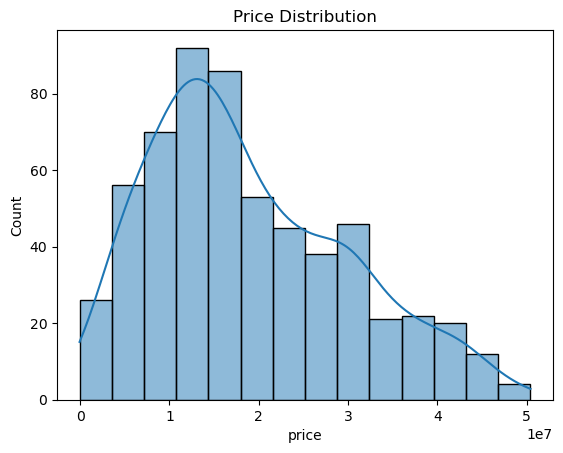

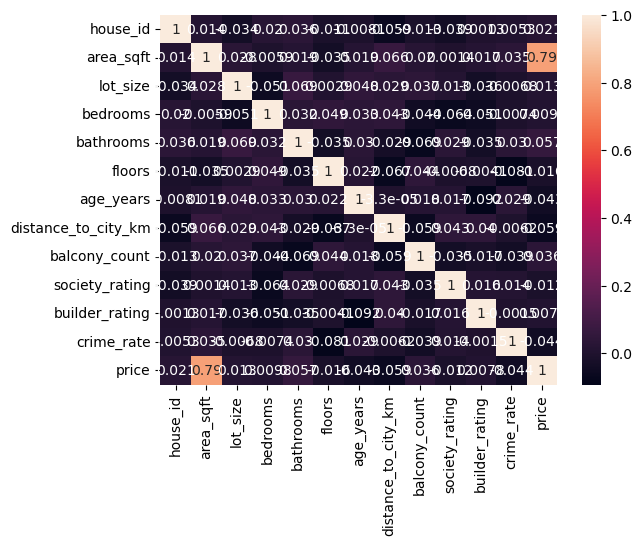

In [64]:
# Price distribution
sns.histplot(df["price"], kde=True)
plt.title("Price Distribution")
plt.show()

# Correlation
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [65]:
df = df.drop("house_id", axis=1)

In [66]:
# define features
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['area_per_room'] = df['area_sqft'] / df['bedrooms']
df['bathroom_ratio'] = df['bathrooms'] / df['bedrooms']
df['luxury_score'] = (
    df['builder_rating'] +
    df['society_rating'] +
    df['balcony_count']
)
df['location_score'] = (
    df['distance_to_city_km'] * -1 +   # closer = better
    df['crime_rate'] * -2              # safer = better
)

In [79]:
df = df.dropna(subset=['price'])
df['price'] = np.log1p(df['price'])

In [103]:
X = df.drop('price', axis=1)
Y = df['price']

In [104]:
#  Define numerical and categorical features
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# Define transformers
num_transformer = StandardScaler()  
cat_transformer = OneHotEncoder(handle_unknown='ignore')

# Combine transformers into a preprocessor
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

In [105]:
# Split into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Display the shape of the data
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (472, 23)
Testing set shape: (119, 23)


In [106]:
# First, check and handle NaN values in Y_train
# Option 1: Remove rows with NaN values
mask = ~np.isnan(Y_train)
X_train_clean = X_train[mask]
Y_train_clean = Y_train[mask]

# Define the pipeline
pipe = Pipeline([
    ("pre", preprocessor),
    ("lr", LinearRegression())
])

# Train the model with clean data
pipe.fit(X_train_clean, Y_train_clean)


,steps,"[('pre', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [107]:
# Make predictions
Y_pred_log = pipe.predict(X_test)
Y_pred = np.expm1(Y_pred_log)
Y_test_actual = np.expm1(Y_test)

In [109]:
# Evaluation
r2 = r2_score(Y_test_actual, Y_pred)
print("R2:", r2)

mae = mean_absolute_error(Y_test_actual, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test_actual, Y_pred))


print("MAE:", mae)
print("RMSE:", rmse)


R2: 0.8688145200783426
MAE: 2915441.420688475
RMSE: 4230053.370922249


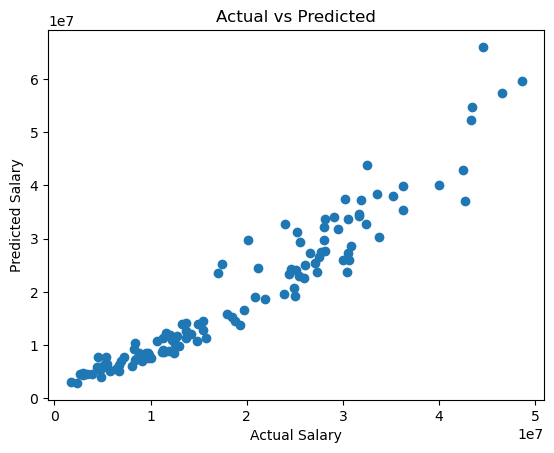

In [101]:
# ACTUAL vs PREDICTED GRAPH
plt.figure()
plt.scatter(Y_test_actual, Y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

In [102]:
# FEATURE IMPORTANCE
model = pipe.named_steps["lr"]
feature_names = pipe.named_steps["pre"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": model.coef_
})

coef_df["impact_%"] = (np.exp(coef_df["coef"]) - 1) * 100

coef_df = coef_df.sort_values(by="coef", ascending=False)
coef_df.head(10)

,feature,coef,impact_%
0,num__area_sqft,0.611106,84.246810
18,cat__location_Urban,0.279818,32.288889
24,cat__property_type_Villa,0.201529,22.327179
19,cat__furnishing_status_Fully-Furnished,0.109444,11.565814
15,num__location_score,0.065287,6.746516
25,cat__facing_direction_East,0.055780,5.736460
34,cat__renovation_status_Not Renovated,0.034314,3.490977
17,cat__location_Suburban,0.032752,3.329414
11,num__total_rooms,0.028484,2.889334
2,num__bedrooms,0.024509,2.481187
